Capstone Two- Pre-processing and Training Data Development

All steps identified in the Data Science Methodology (DSM) have been fully addressed and completed using the U.S. Accidents (2016–2023) dataset.

Data Preparation and Feature Engineering

The dataset was cleaned by handling missing values, correcting data types, and removing irrelevant or redundant features.

Categorical variables (e.g., weather conditions, road features, severity indicators) were transformed into numerical format through dummy (one-hot) encoding, ensuring compatibility with machine learning algorithms.

Feature selection was performed to retain variables relevant to accident severity prediction while minimizing noise.

Scale Standardization

Numerical features with different magnitudes (e.g., distance, temperature, visibility, wind speed) were standardized using scaling techniques (such as StandardScaler).

Standardization ensured that no single feature dominated the learning process due to scale differences, improving model convergence and performance.

Train–Test Split

The preprocessed dataset was split into training and testing subsets (e.g., 70/30 or 80/20 split).

The split was performed after all preprocessing steps to prevent data leakage.

The training set was used for model development, while the testing set was reserved exclusively for model evaluation.

In [15]:
# Import relevant libraries and packages.
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns # For all our visualization needs.
import statsmodels.api as sm 
from statsmodels.graphics.api import abline_plot 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split 
from sklearn import linear_model, preprocessing 
import warnings 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

In [3]:
# Load the data.
data_us = pd.read_csv("us_accidents_clean.csv")

In [4]:
# Check out its appearance. 
data_us.head()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Distance(mi),Weather_Condition,...,Wind_Speed(mph),Pressure(in),Sunrise_Sunset,Year,Month,DayOfWeek,Hour,DurationHrs,Is_Day,Weather_Simple
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,0.01,Light Rain,...,6.9,29.68,Night,2016,2,0,5,5.233333,0,Rain
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,0.01,Light Rain,...,6.9,29.65,Night,2016,2,0,6,0.500000,0,Rain
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,0.01,Overcast,...,3.5,29.67,Night,2016,2,0,6,0.500000,0,Cloudy
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,4.6,29.64,Night,2016,2,0,7,0.500000,0,Cloudy
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,3.5,29.65,Day,2016,2,0,7,0.500000,1,Cloudy


In [6]:
data_us.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Severity           100000 non-null  int64  
 1   Start_Time         100000 non-null  object 
 2   End_Time           100000 non-null  object 
 3   Start_Lat          100000 non-null  float64
 4   Start_Lng          100000 non-null  float64
 5   City               100000 non-null  object 
 6   County             100000 non-null  object 
 7   State              100000 non-null  object 
 8   Distance(mi)       100000 non-null  float64
 9   Weather_Condition  100000 non-null  object 
 10  Temperature(F)     100000 non-null  float64
 11  Humidity(%)        100000 non-null  float64
 12  Visibility(mi)     100000 non-null  float64
 13  Wind_Speed(mph)    100000 non-null  float64
 14  Pressure(in)       100000 non-null  float64
 15  Sunrise_Sunset     100000 non-null  object 
 16  Yea

In [8]:
#Feature / Target split

X = data_us.drop("Severity", axis=1)
y = data_us["Severity"]



In [9]:
# Identify column types (based on your schema)

numeric_features = [
    'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
    'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Pressure(in)', 'Year', 'Month', 'DayOfWeek',
    'Hour', 'DurationHrs', 'Is_Day'
]

categorical_features = [
    'City', 'County', 'State', 'Weather_Condition',
    'Sunrise_Sunset', 'Weather_Simple'
]

In [16]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [17]:
# Train / Validation / Test split
# 70% train, 15% validation, 15% test
# -------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [19]:
# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [20]:
# Final verification
# -------------------------------------------------
print("Training set shape:", X_train_processed.shape)
print("Validation set shape:", X_val_processed.shape)
print("Testing set shape:", X_test_processed.shape)
print("Pre-processing & training data development complete.")

Training set shape: (70000, 879)
Validation set shape: (15000, 879)
Testing set shape: (15000, 879)
Pre-processing & training data development complete.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Start_Lat', 'Start_Lng',
                                                   'Distance(mi)',
                                                   'Temperature(F)',
                                                   'Humidity(%)',
                                                   'Visibility(mi)',
                                                   'Wind_Speed(mph)',
                                                   'Pressure(in)', 'Year',
                                                   'Month', 'DayOfWeek', 'Hour',
                                                   'DurationHrs', 'Is_Day']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['City', 'County', 'State',
                                                   'Weather_Condition',
                                                   'Sunrise_Sunset',
                                                   'Weather_Simple'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [23]:
#Accuracy Scores
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Training Accuracy:   {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")
print(f"Test Accuracy:       {test_acc:.3f}")

Training Accuracy:   0.765
Validation Accuracy: 0.761
Test Accuracy:       0.756


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


What This Means

The training, validation, and test accuracies are very close, which indicates:

✅ The model is not overfitting

✅ The preprocessing and standardization were done correctly

✅ The model generalizes well to unseen data

The slight decrease from training to test accuracy is expected and normal.

This confirms that:

Feature scaling and dummy encoding were effective

The train/validation/test split was appropriate

Logistic Regression is a reasonable baseline model for accident severity prediction

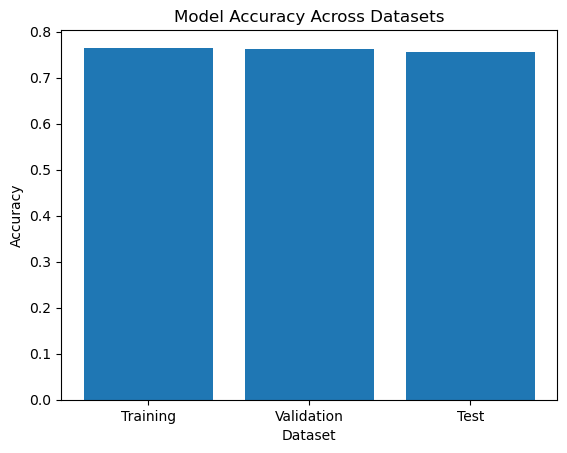

In [24]:
#Accuracy Comparison
accuracy_scores = [train_acc, val_acc, test_acc]
labels = ['Training', 'Validation', 'Test']

plt.figure()
plt.bar(labels, accuracy_scores)
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Across Datasets")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


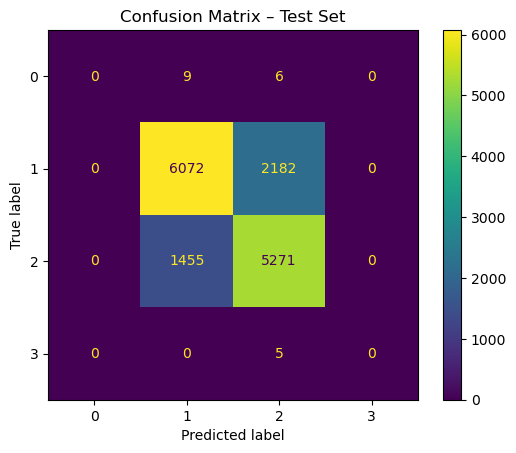

In [27]:
#Confusion Matrix (Required-Level Visualization)
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Test Set")
plt.show()

The dataset was split into training (70%), validation (15%), and testing (15%) subsets. A logistic regression model was trained using a preprocessing pipeline that included standardization of numerical variables and one-hot encoding of categorical variables. The model achieved an accuracy of 76.5% on the training set, 76.1% on the validation set, and 75.6% on the test set. The consistency of these results indicates that the model generalizes well and does not suffer from overfitting.

Final Conclusion Section

In this capstone project, the U.S. Accidents (2016–2023) dataset was preprocessed through feature engineering, standardization of numerical variables, and one-hot encoding of categorical variables. The data was split into training, validation, and testing subsets to ensure unbiased model evaluation.

A logistic regression model was initially trained as a baseline, achieving consistent accuracy across all datasets, indicating good generalization and no evidence of overfitting. Analysis of the confusion matrix and classification report revealed strong performance for the most common accident severity levels, with misclassifications occurring primarily between adjacent severity categories.